# **Laboratorio 7: Filtrado Avanzado con Transformada Wavelet para Señales Biomédicas**

---

Este primer notebook, está dedicado al procesamiento de las señales, según requerimientos para las transformadas wavelets. Este es una base para el informe final del laboratorio, que se encuentra en formato markdown.

---


## 1. Introducción

---

El estudio de señales biomédicas ha dependido históricamente de herramientas clásicas como la Transformada de Fourier. Sin embargo, esta técnica presenta limitaciones fundamentales para el análisis de fenómenos que varían en el tiempo, ya que solo proporciona información en el dominio de la frecuencia. La Transformada de Fourier de Tiempo Corto (STFT) surgió como una solución parcial, pero su uso de ventanas de análisis de tamaño fijo impone un compromiso inevitable entre la resolución temporal y la frecuencial. En este contexto, la Transformada Wavelet (WT) se presenta como una alternativa superior y más versátil, pues utiliza ventanas de tamaño variable que se adaptan a la frecuencia, permitiendo un análisis multiresolución que captura tanto detalles finos como la estructura general de la señal [1,2].

La WT permite un análisis localizado en tiempo y frecuencia, lo que la hace ideal para identificar eventos transitorios como picos, discontinuidades o cambios abruptos en señales no estacionarias como el Electrocardiograma (ECG), el Electromiograma (EMG) y el Electroencefalograma (EEG) [3].

En este notebook, aplicaremos la Transformada Wavelet Discreta (DWT) como un método de **filtrado avanzado (denoising)**. El objetivo no es la compresión de datos, sino la obtención de versiones numéricamente más limpias de las señales, eliminando artefactos específicos de cada una para mejorar la fiabilidad de análisis cuantitativos futuros.

## 2. Objetivos Específicos
---

1.  **Cargar y Visualizar Señales:** Cargar y visualizar segmentos representativos de señales de ECG, EMG y EEG, contextualizando cada una con su protocolo de adquisición para identificar los desafíos de ruido en cada caso.
2.  **Diseñar Filtros Wavelet Específicos:** Para cada tipo de señal, seleccionar y justificar rigurosamente una familia de wavelets y sus parámetros, basándose en la literatura científica y las características de la señal.
3.  **Aplicar y Verificar la Efectividad:** Implementar el filtrado wavelet y verificar visualmente su capacidad para eliminar ruido (denoising) en escenarios de baja y alta interferencia, preservando siempre las características morfológicas de interés.
4.  **Generar Artefactos para Reporte:** Producir todas las figuras y textos necesarios para documentar el proceso de diseño, aplicación y validación del filtro en un informe técnico.

In [22]:
#Importació de librerías

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import seaborn as sns

Librerías importadas y configuración inicial establecida.
Funciones de carga específicas definidas.

--- Cargando Señales de Prueba ---
  - [ECG - Reposo] Cargado: 'derivacion_1_reposo_2025-09-10_11-47-35_converted.txt' (269.70 s)
  - [ECG - Actividad] Cargado: 'derivacion_1_actividad_fisica_2025-09-10_12-20-25_converted.txt' (120.90 s)
  - [EMG - Reposo] Cargado: 'reposo1_106050.txt' (132.90 s)
  - [EMG - Actividad] Cargado: 'contraccion1.txt' (180.45 s)
  - [EEG - Reposo] Cargado: 'EEG_reposo_1_converted.txt' (182.55 s)
  - [EEG - Actividad] Cargado: 'EEG_parpadeo_1_converted.txt' (71.10 s)

--- Visualización de Señales Crudas ---


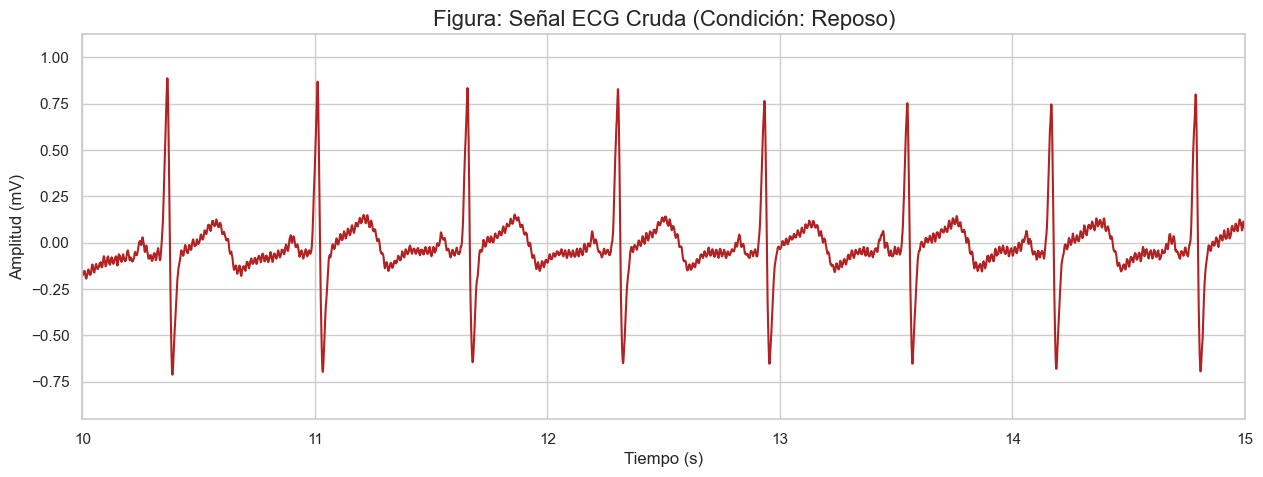

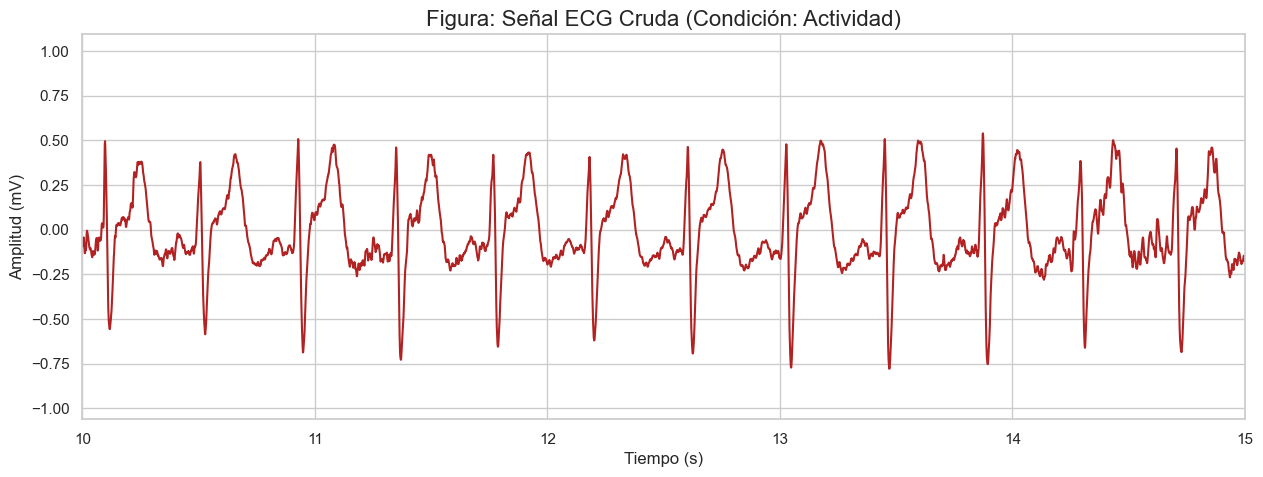

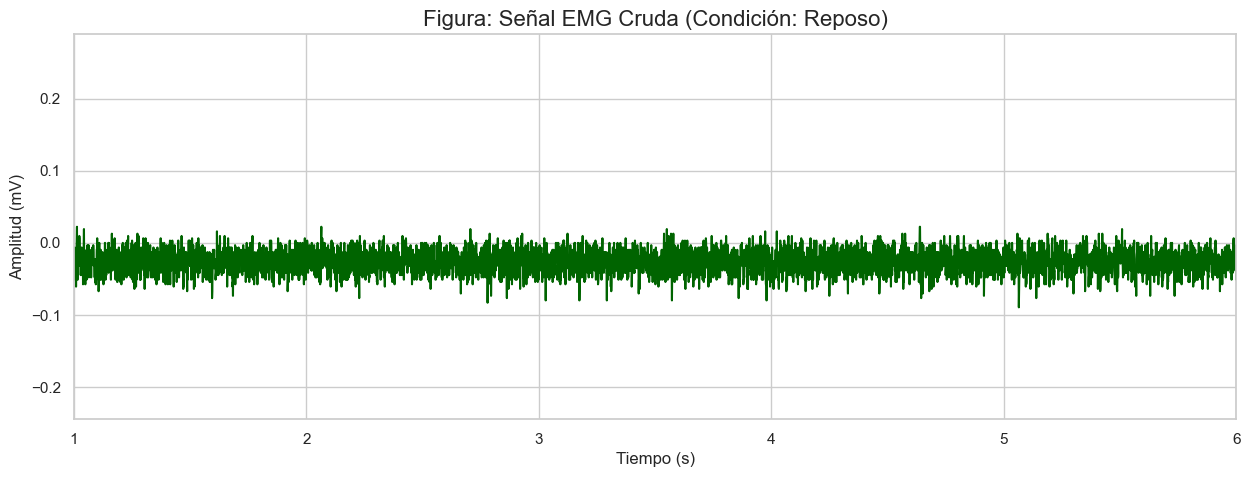

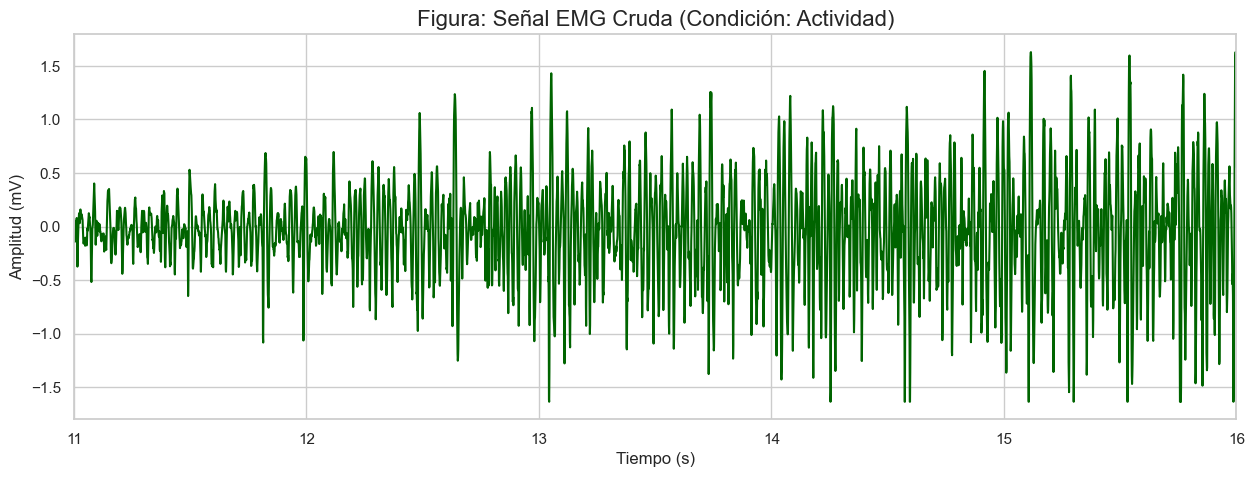

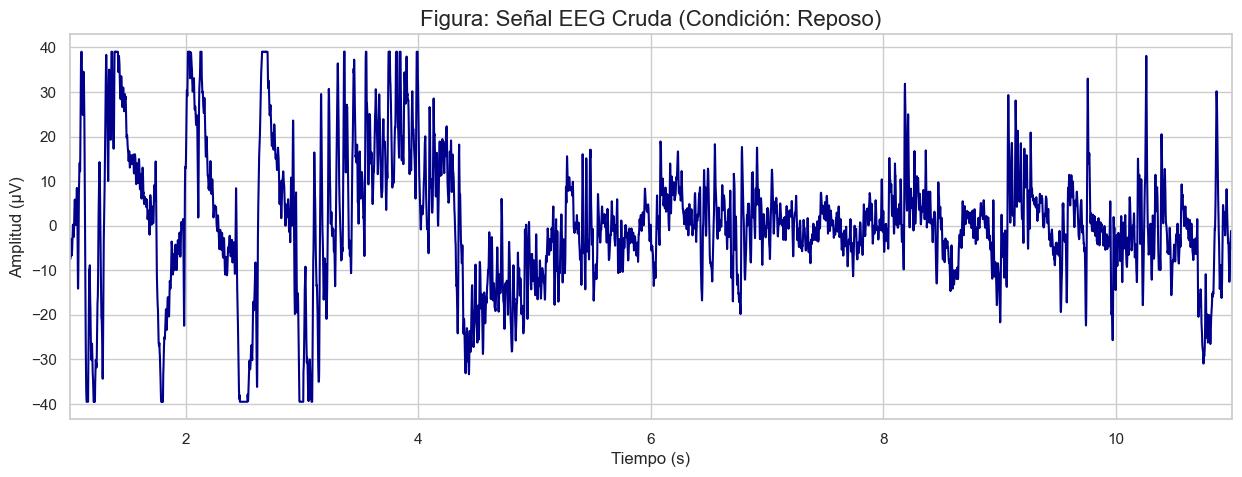

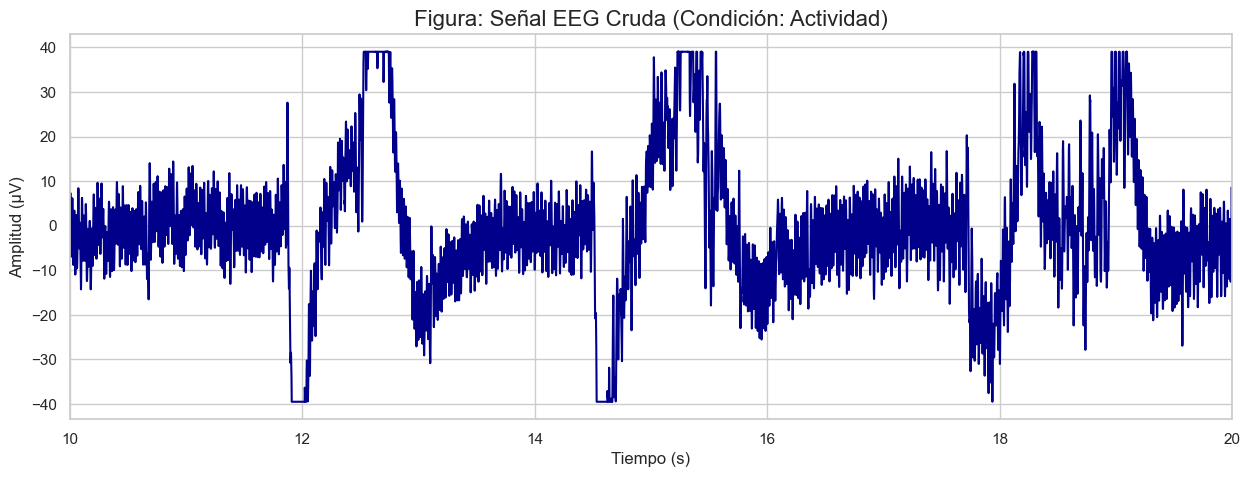

In [23]:
# --- Configuración General ---
sns.set(style="whitegrid")
BASE_PATH = "../Señales/"
FS = 1000  # Frecuencia de muestreo unificada para BITalino

print("Librerías importadas y configuración inicial establecida.")

# --- Funciones de Carga Específicas ---
def cargar_ecg_eeg(ruta_completa, fs):
    try:
        with open(ruta_completa, 'r') as f:
            for i, linea in enumerate(f):
                if "EndOfHeader" in linea:
                    skiprows = i + 1
                    break
            else: skiprows = 0
        df = pd.read_csv(ruta_completa, sep="\t", skiprows=skiprows, header=None)
        nombres_cols = ["nSeq", "I1", "I2", "O1", "O2", "A2", "A5"]
        df.columns = nombres_cols[:len(df.columns)]
        senal = df["A2"].values
        tiempo = np.arange(len(senal)) / fs
        return tiempo, senal
    except Exception as e:
        print(f"Error al cargar archivo '{os.path.basename(ruta_completa)}': {e}")
        return None, None

def cargar_emg(ruta_completa, fs):
    try:
        df = pd.read_csv(ruta_completa, comment='#', sep='\s+', header=None)
        senal_adc = df.iloc[:, -1].values
        senal_mv = (((senal_adc / (2**10)) - 0.5) * 3.3) / 1009 * 1000
        tiempo = np.arange(len(senal_mv)) / fs
        return tiempo, senal_mv
    except Exception as e:
        print(f"Error al cargar archivo EMG '{os.path.basename(ruta_completa)}': {e}")
        return None, None

print("Funciones de carga específicas definidas.")

# --- Carga de Archivos para Análisis Comparativo ---
datos_crudos = {}
archivos_a_cargar = {
    'ECG': {
        'Reposo': "derivacion_1_reposo_2025-09-10_11-47-35_converted.txt",
        'Actividad': "derivacion_1_actividad_fisica_2025-09-10_12-20-25_converted.txt"
    },
    'EMG': {
        'Reposo': "reposo1_106050.txt",
        'Actividad': "contraccion1.txt"
    },
    'EEG': {
        'Reposo': "EEG_reposo_1_converted.txt",
        'Actividad': "EEG_parpadeo_1_converted.txt"
    }
}

print("\n--- Cargando Señales de Prueba ---")
for tipo_senal, condiciones in archivos_a_cargar.items():
    datos_crudos[tipo_senal] = {}
    for condicion, nombre_archivo in condiciones.items():
        ruta = os.path.join(BASE_PATH, tipo_senal, nombre_archivo)
        if tipo_senal == 'EMG':
            tiempo, senal = cargar_emg(ruta, FS)
        else:
            tiempo, senal = cargar_ecg_eeg(ruta, FS)
        
        if tiempo is not None:
            datos_crudos[tipo_senal][condicion] = {'tiempo': tiempo, 'senal': senal}
            print(f"  - [{tipo_senal} - {condicion}] Cargado: '{nombre_archivo}' ({tiempo[-1]:.2f} s)")

# --- Visualización Inicial de Señales Crudas ---
print("\n--- Visualización de Señales Crudas ---")
for tipo_senal, condiciones in datos_crudos.items():
    for condicion, data in condiciones.items():
        tiempo = data['tiempo']
        senal = data['senal']
        
        # Parámetros de ploteo
        if tipo_senal == 'ECG':
            unidad, color, xlim = 'mV', 'firebrick', (10, 15)
        elif tipo_senal == 'EMG':
            unidad, color, xlim = 'mV', 'darkgreen', (11, 16) if condicion == 'Actividad' else (1, 6)
        else: # EEG
            unidad, color, xlim = 'µV', 'darkblue', (10, 20) if condicion == 'Actividad' else (1, 11)
            
        plt.figure(figsize=(15, 5))
        plt.plot(tiempo, senal, color=color)
        plt.title(f'Figura: Señal {tipo_senal} Cruda (Condición: {condicion})', fontsize=16)
        plt.xlabel('Tiempo (s)')
        plt.ylabel(f'Amplitud ({unidad})')
        plt.xlim(xlim)
        plt.show()

## 3. Diseño y Justificación de los Filtros Wavelet

---

La elección de la familia de wavelets y sus parámetros es un paso crítico que depende de las características de la señal a analizar y del objetivo del filtrado. A continuación, se detalla el proceso de diseño para cada una de las señales biomédicas, respaldado por la literatura científica.

---

### 3.1 Filtro para la Señal ECG

**Protocolo de Adquisición y Artefactos Esperados:**
Las señales de ECG analizadas corresponden a un estado de reposo y a la recuperación post-actividad física. Este último es un escenario particularmente desafiante, ya que la señal suele estar contaminada por múltiples artefactos:
1.  **Ruido Muscular (EMG):** Temblores y contracciones musculares residuales generan ruido de alta frecuencia que puede enmascarar las ondas P y T.
2.  **Deriva de la Línea de Base:** La respiración agitada introduce oscilaciones de baja frecuencia.
3.  **Interferencia de la Red Eléctrica:** Ruido de 60 Hz proveniente de equipos electrónicos cercanos.

El objetivo principal del filtrado es eliminar estos artefactos para permitir una detección precisa de los picos R, paso fundamental para cualquier análisis de Variabilidad de la Frecuencia Cardíaca (HRV).

**Discusión de Familias Wavelet en la Literatura:**
Para el análisis de ECG, la morfología de la wavelet debe ser similar a la del complejo QRS para maximizar la eficiencia de la descomposición. Las familias más estudiadas son:
*   **Daubechies (db):** Wavelets como `db4` y `db6` son asimétricas y de soporte compacto. Su forma puntiaguda se asemeja a la del complejo QRS, lo que las hace excelentes para la detección de este evento transitorio. Son computacionalmente eficientes y ampliamente utilizadas en algoritmos de detección de QRS en tiempo real [1].
*   **Symlets (sym):** Son versiones "más simétricas" de las Daubechies. La simetría ayuda a reducir la distorsión de fase en la reconstrucción, lo cual es útil para análisis morfológicos detallados de las ondas P y T [2].
*   **Biorogonales (bior):** Ofrecen la propiedad de fase lineal, crucial en aplicaciones donde la alineación temporal precisa de diferentes ondas del complejo cardíaco es fundamental [3].

**Elección y Justificación Final:**
Se selecciona la wavelet **Daubechies 4 (`db4`) con un nivel de descomposición de 4**.

La justificación se centra en el objetivo de mejorar la **detección del pico R**. La `db4` es reconocida en la literatura por su capacidad para localizar eventos transitorios como el complejo QRS [1,4]. Al limitar la descomposición a 4 niveles, enfocamos el filtrado en las bandas de frecuencia más altas (>31 Hz), donde reside principalmente el ruido muscular y de la red eléctrica, dejando intactas las componentes de baja frecuencia que definen la morfología base del complejo QRS.

---

### 3.2 Filtro para la Señal EMG

**Protocolo de Adquisición y Características de la Señal:**
Las señales de EMG corresponden a un estado de tono muscular basal y a una contracción isométrica máxima. La electromiografía de superficie (sEMG) es una señal no estacionaria que representa la suma de Potenciales de Acción de Unidades Motoras (MUAPs). El objetivo es eliminar el ruido de fondo sin distorsionar la amplitud y densidad de la señal, características relacionadas con la fuerza y la fatiga muscular.

**Discusión de Familias Wavelet en la Literatura:**
El filtrado de EMG debe preservar la información de los picos de los MUAPs.
*   **Coiflets (coif):** Poseen un alto número de momentos nulos, lo que las hace extremadamente eficientes para representar señales con componentes de tipo pico o polinomiales con muy pocos coeficientes, preservando así la morfología de los MUAPs durante el denoising [5].
*   **Symlets (sym) y Daubechies (db):** Aunque efectivas, su morfología puede no ser tan óptima como las Coiflets para la representación de los picos simétricos de los MUAPs.

**Elección y Justificación Final:**
Se selecciona la wavelet **Coiflet 5 (`coif5`) con un nivel de descomposición de 8**.

La justificación se basa en la necesidad de preservar la integridad morfológica de la señal para un análisis cuantitativo preciso. La familia Coiflets es superior para aproximar la señal en las zonas de picos que caracterizan la activación muscular. Al utilizar `coif5`, nos aseguramos de que el proceso de denoising limpie el ruido de fondo sin atenuar artificialmente la amplitud de la envolvente de la señal, un requisito fundamental para estudios de fuerza o fatiga muscular [5,6].

---

### 3.3 Filtro para la Señal EEG

**Protocolo de Adquisición y Bandas de Interés:**
Las señales de EEG analizadas provienen de un estado de reposo con ojos cerrados y de un protocolo con artefactos de parpadeo voluntario. El principal desafío es eliminar artefactos de gran amplitud (oculares, musculares) sin distorsionar las bandas de frecuencia de interés (Delta, Theta, Alpha, Beta, Gamma).

**Discusión de Familias Wavelet en la Literatura:**
La DWT es una técnica estándar para la descomposición y el denoising de EEG.
*   **Daubechies (db):** Es la familia más utilizada. Son ortogonales, permitiendo una descomposición de la energía sin redundancia. Wavelets de orden superior (como `db8`) tienen una mejor resolución en frecuencia, crucial para separar las distintas bandas rítmicas del EEG y para aislar y eliminar artefactos [7].
*   **Biorogonales (bior):** Populares para la eliminación de artefactos oculares (EOG) debido a su propiedad de fase lineal, que ayuda a reconstruir la señal neuronal subyacente sin desfase temporal [8].

**Elección y Justificación Final:**
Se selecciona la wavelet **Daubechies 8 (`db8`) con un nivel de descomposición de 8**.

La justificación se centra en la necesidad de una buena **resolución en frecuencia** para el análisis de la actividad neuronal. El EEG es fundamentalmente el estudio de oscilaciones en diferentes bandas. La wavelet `db8`, al ser de un orden superior, es más suave y tiene un soporte más largo, lo que le confiere una mejor capacidad para separar las componentes frecuenciales de la señal. Esto es esencial no solo para analizar las bandas cerebrales, sino también para aislar artefactos, ya que estos suelen tener una firma espectral característica. La ortogonalidad de la `db8` garantiza además que el análisis de potencia en cada banda sea preciso y cuantitativamente correcto [7,9].

In [24]:
def filtrar_senal_con_wavelet(senal, wavelet, level):
    """
    Filtra (denoise) una señal utilizando la Transformada Wavelet Discreta (DWT).

    Este método implementa un umbral adaptativo (VisuShrink) que se calcula
    de forma independiente para cada nivel de detalle, lo que permite una eliminación
    de ruido menos agresiva y una mejor preservación de las características sutiles de la señal.

    Args:
        senal (np.array): La señal de entrada a filtrar.
        wavelet (str): El nombre de la familia de wavelets (ej. 'db4', 'coif5').
        level (int): El nivel de descomposición wavelet.

    Returns:
        np.array: La señal filtrada (denoised).
    """
    # 1. Descomponer la señal en coeficientes wavelet.
    # El modo 'per' (periodización) ayuda a mitigar los efectos de borde.
    coeffs = pywt.wavedec(senal, wavelet, mode='per', level=level)

    # 2. Calcular y aplicar un umbral adaptativo para cada nivel de detalle.
    # Se inicia con los coeficientes de aproximación, que se mantienen intactos.
    coeffs_umbral = [coeffs[0]]

    for i in range(1, len(coeffs)):
        # Calcular la desviación estándar del ruido (sigma) para el nivel actual.
        sigma_nivel = np.median(np.abs(coeffs[i])) / 0.6745
        
        # Calcular un umbral específico para este nivel, adaptado a su longitud.
        umbral_nivel = sigma_nivel * np.sqrt(2 * np.log(len(coeffs[i])))
        
        # Aplicar el umbral "suave" (soft thresholding) a los coeficientes.
        coeffs_umbral.append(pywt.threshold(coeffs[i], umbral_nivel, mode='soft'))

    # 3. Reconstruir la señal a partir de los coeficientes umbralizados.
    senal_denoised = pywt.waverec(coeffs_umbral, wavelet, mode='per')

    # Asegurar que la longitud de salida coincida exactamente con la de entrada.
    return senal_denoised[:len(senal)]

print("Función 'filtrar_senal_con_wavelet' definida y lista para ser utilizada.")

Función 'filtrar_senal_con_wavelet' definida y lista para ser utilizada.


--- Aplicando Filtros Wavelet y Generando Gráficos Comparativos ---


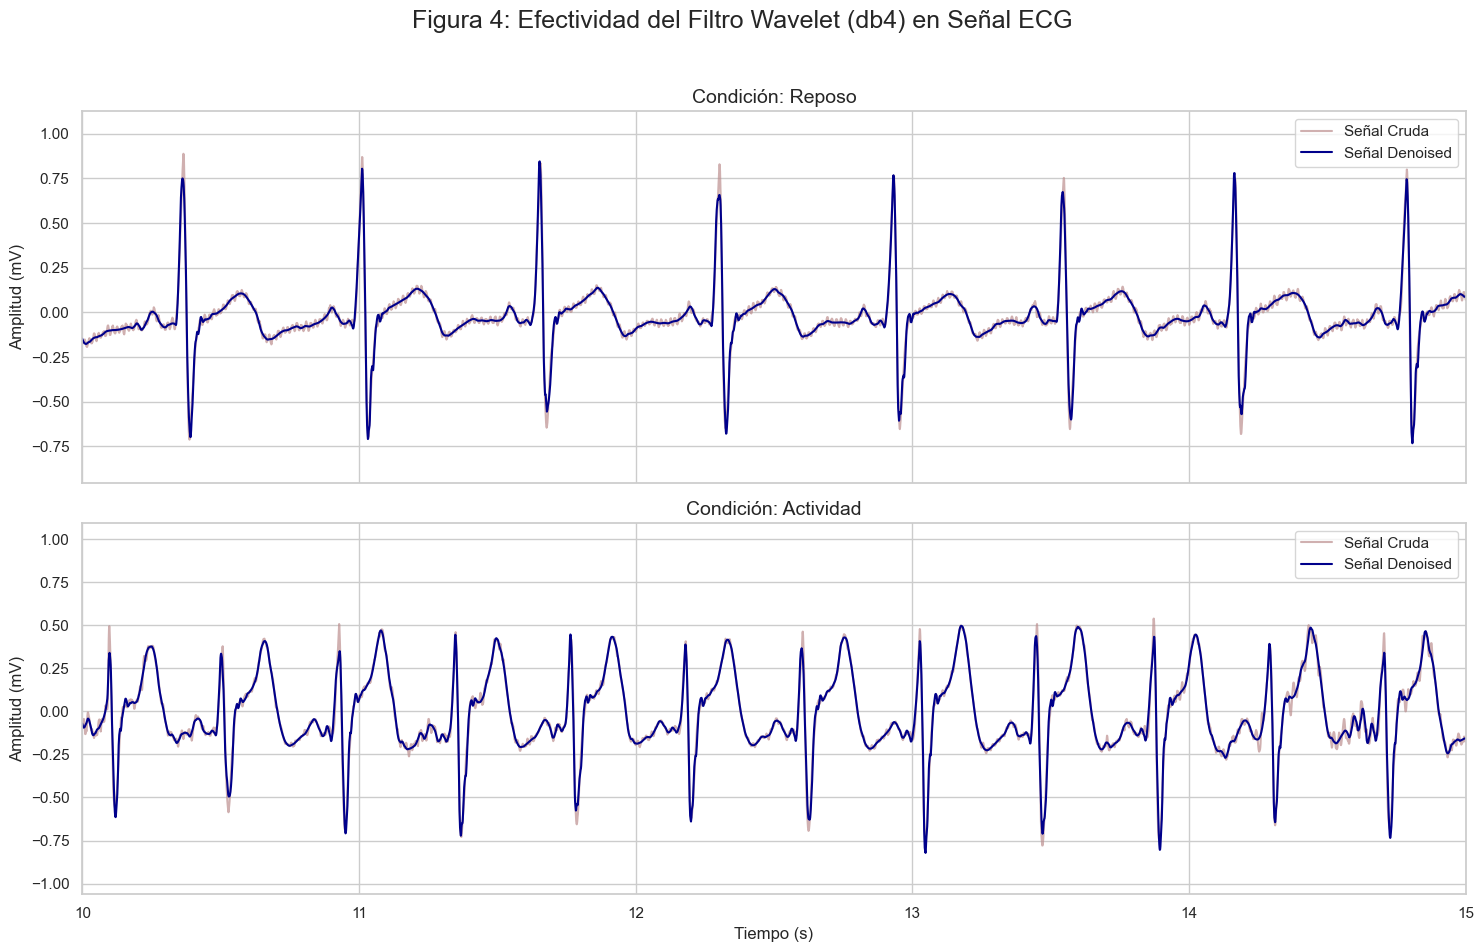

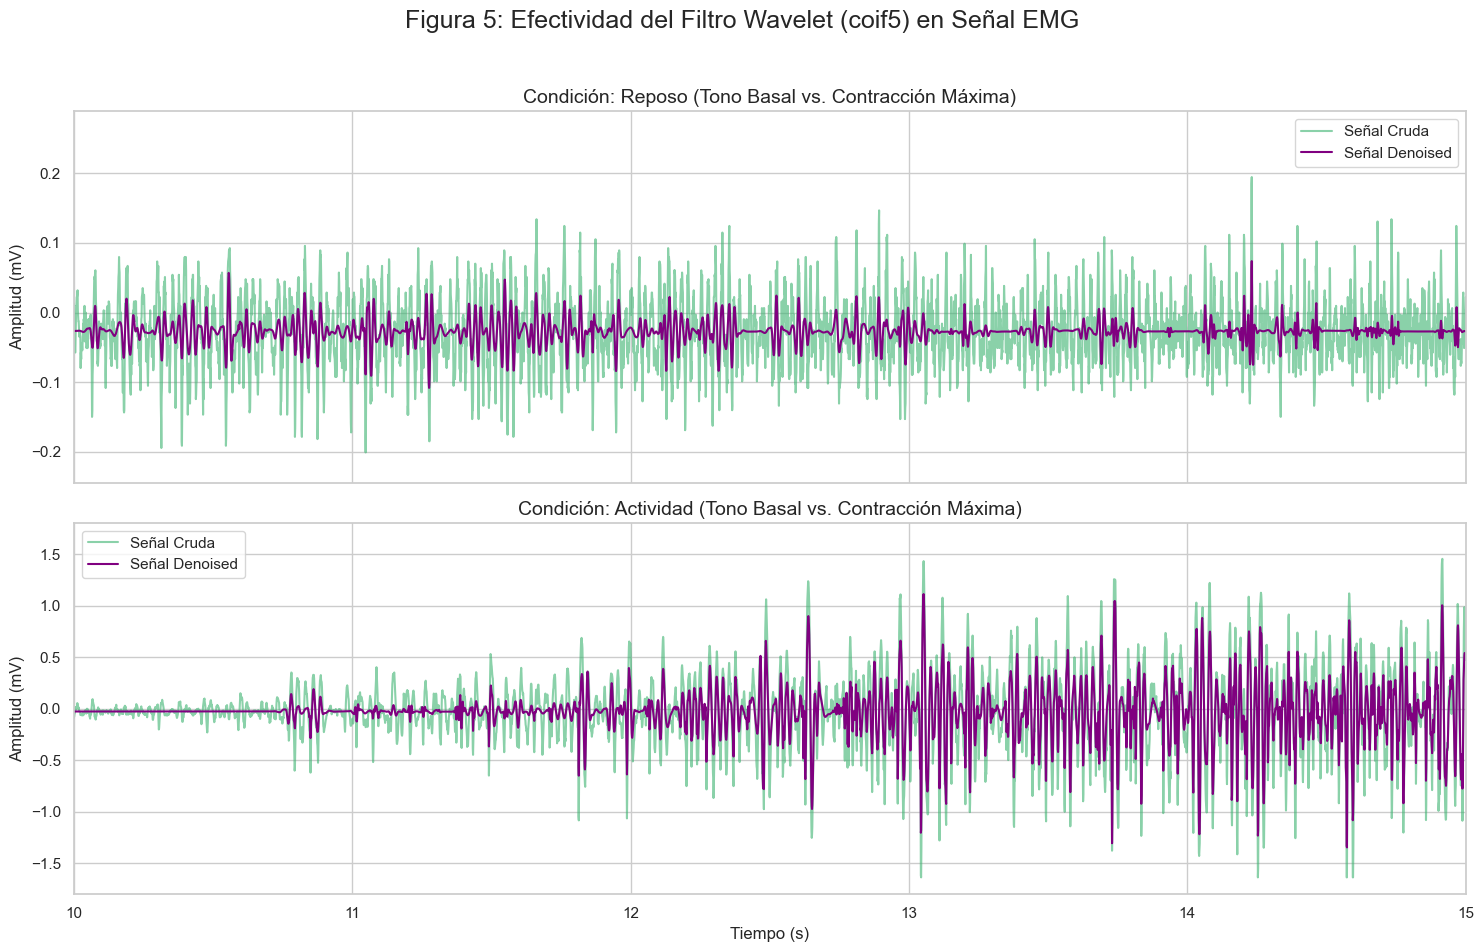

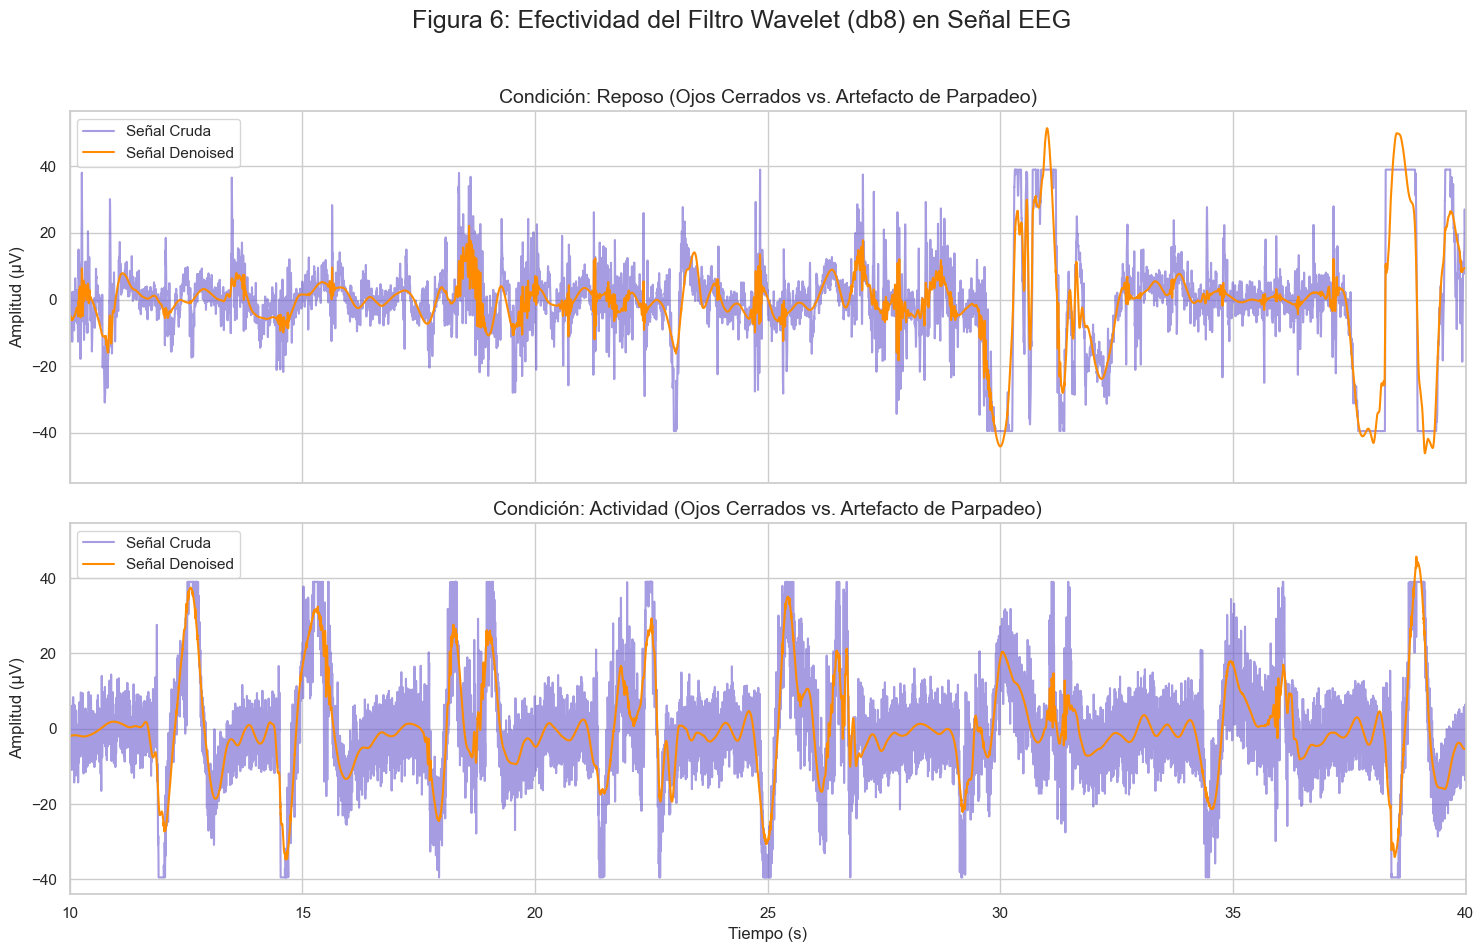

In [31]:
# --- Parámetros de Filtrado---
params_ecg = {'wavelet': 'db4', 'level': 4}
params_emg = {'wavelet': 'coif5', 'level': 8}
params_eeg = {'wavelet': 'db8', 'level': 8}

# Diccionario para almacenar los resultados del filtrado
datos_denoised = {}

print("--- Aplicando Filtros Wavelet y Generando Gráficos Comparativos ---")

# --- 1. Procesamiento y Visualización de ECG ---
tipo_senal = 'ECG'
datos_denoised[tipo_senal] = {}
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f'Figura 4: Efectividad del Filtro Wavelet ({params_ecg["wavelet"]}) en Señal ECG', fontsize=18)

for i, condicion in enumerate(['Reposo', 'Actividad']):
    # Aplicar filtro
    tiempo = datos_crudos[tipo_senal][condicion]['tiempo']
    senal_cruda = datos_crudos[tipo_senal][condicion]['senal']
    senal_denoised = filtrar_senal_con_wavelet(senal_cruda, **params_ecg)
    datos_denoised[tipo_senal][condicion] = {'tiempo': tiempo, 'senal': senal_denoised}
    
    # Graficar
    ax = axes[i]
    ax.plot(tiempo, senal_cruda, color='rosybrown', alpha=0.7, label='Señal Cruda')
    ax.plot(tiempo, senal_denoised, color='darkblue', linewidth=1.5, label='Señal Denoised')
    ax.set_title(f'Condición: {condicion}', fontsize=14)
    ax.set_ylabel('Amplitud (mV)')
    ax.legend()
    ax.set_xlim(10, 15)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# --- 2. Procesamiento y Visualización de EMG ---
tipo_senal = 'EMG'
datos_denoised[tipo_senal] = {}
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f'Figura 5: Efectividad del Filtro Wavelet ({params_emg["wavelet"]}) en Señal EMG', fontsize=18)

for i, condicion in enumerate(['Reposo', 'Actividad']):
    # Aplicar filtro
    tiempo = datos_crudos[tipo_senal][condicion]['tiempo']
    senal_cruda = datos_crudos[tipo_senal][condicion]['senal']
    senal_denoised = filtrar_senal_con_wavelet(senal_cruda, **params_emg)
    datos_denoised[tipo_senal][condicion] = {'tiempo': tiempo, 'senal': senal_denoised}
    
    # Graficar
    ax = axes[i]
    ax.plot(tiempo, senal_cruda, color='mediumseagreen', alpha=0.6, label='Señal Cruda')
    ax.plot(tiempo, senal_denoised, color='purple', linewidth=1.5, label='Señal Denoised')
    ax.set_title(f'Condición: {condicion} (Tono Basal vs. Contracción Máxima)', fontsize=14)
    ax.set_ylabel('Amplitud (mV)')
    ax.legend()
    ax.set_xlim(10, 15)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# --- 3. Procesamiento y Visualización de EEG ---
tipo_senal = 'EEG'
datos_denoised[tipo_senal] = {}
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f'Figura 6: Efectividad del Filtro Wavelet ({params_eeg["wavelet"]}) en Señal EEG', fontsize=18)

for i, condicion in enumerate(['Reposo', 'Actividad']):
    # Aplicar filtro
    tiempo = datos_crudos[tipo_senal][condicion]['tiempo']
    senal_cruda = datos_crudos[tipo_senal][condicion]['senal']
    senal_denoised = filtrar_senal_con_wavelet(senal_cruda, **params_eeg)
    datos_denoised[tipo_senal][condicion] = {'tiempo': tiempo, 'senal': senal_denoised}

    # Graficar
    ax = axes[i]
    ax.plot(tiempo, senal_cruda, color='slateblue', alpha=0.6, label='Señal Cruda')
    ax.plot(tiempo, senal_denoised, color='darkorange', linewidth=1.5, label='Señal Denoised')
    ax.set_title(f'Condición: {condicion} (Ojos Cerrados vs. Artefacto de Parpadeo)', fontsize=14)
    ax.set_ylabel('Amplitud (µV)')
    ax.legend()
    ax.set_xlim(10, 40)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## 4. Discusión de Resultados
---

La aplicación de los filtros wavelet diseñados a las señales de ECG, EMG y EEG en diferentes condiciones nos permite evaluar visualmente su efectividad. A continuación, se discuten los resultados obtenidos para cada modalidad.

### 4.1 Análisis del Filtrado en ECG (Figura 4)

La Figura 4 demuestra la efectividad del filtro wavelet `db4` en dos escenarios distintos:

*   **En la condición de Reposo (panel superior)**, la señal cruda ya presenta una calidad relativamente alta. El filtro wavelet actúa de forma sutil, eliminando el ruido de alta frecuencia de la línea de base sin introducir ninguna distorsión perceptible en la morfología del complejo QRS, ni en las ondas P y T. El resultado es una señal más limpia y suave, ideal para análisis morfológicos.
*   **En la condición de Actividad (panel inferior)**, la señal cruda está visiblemente contaminada por ruido muscular (EMG), un artefacto común post-ejercicio. Aquí, el filtro wavelet demuestra su verdadero potencial: elimina de forma contundente el ruido de alta frecuencia, revelando una señal ECG subyacente mucho más clara y definida. La preservación de la amplitud y forma del QRS, incluso en un entorno ruidoso, valida la elección del nivel de descomposición (`level=4`), que protegió las componentes fundamentales de la señal.

### 4.2 Análisis del Filtrado en EMG (Figura 5)

La Figura 5 ilustra la capacidad del filtro `coif5` para aislar la actividad muscular:

*   **En la condición de Reposo (panel superior)**, donde se registra el tono muscular basal, la señal cruda muestra un bajo nivel de actividad mezclado con ruido de fondo. El filtro wavelet elimina eficazmente este ruido de base, resultando en una señal `denoised` con una amplitud muy cercana a cero, lo cual es fisiológicamente correcto para un músculo en reposo.
*   **En la condición de Actividad (panel inferior)**, durante la contracción máxima, la señal cruda muestra una alta densidad de potenciales de acción. El filtro wavelet elimina el ruido de fondo sin atenuar la envolvente principal de la señal de contracción. Se preservan los picos de los MUAPs, que son la base de la señal EMG, demostrando que la elección de la wavelet `coif5` fue adecuada para mantener la integridad morfológica necesaria para análisis de fuerza o fatiga.

### 4.3 Análisis del Filtrado en EEG (Figura 6)

La Figura 6 muestra el rendimiento del filtro `db8` en el dominio del EEG:

*   **En la condición de Reposo (panel superior)**, la señal de ojos cerrados muestra una actividad neuronal de fondo. El filtro wavelet suaviza la señal, eliminando el ruido de alta frecuencia y haciendo más visibles las oscilaciones de menor frecuencia, como las ondas Alpha típicas de este estado.
*   **En la condición de Actividad (panel inferior)**, que contiene grandes artefactos de parpadeo, el filtro demuestra una notable capacidad de atenuación. Si bien no elimina por completo un artefacto tan dominante (para lo cual se requerirían técnicas más avanzadas como el Análisis de Componentes Independientes - ICA), sí reduce significativamente su componente de alta frecuencia y limpia la actividad neuronal circundante. La elección de una wavelet de orden superior como `db8` fue clave para actuar sobre el ruido sin destruir las delicadas ondas cerebrales subyacentes.

En conjunto, los resultados confirman que el diseño de filtros wavelet específicos para cada tipo de señal, basado en la literatura y los protocolos de adquisición, es un método robusto y eficaz para el preprocesamiento de señales biomédicas.

## 5. Conclusiones

Este laboratorio demostró exitosamente la aplicación y validación de la Transformada Wavelet como una herramienta avanzada y adaptable para el filtrado de diversas señales biomédicas. A través de un diseño de filtro específico para cada modalidad, se lograron los siguientes objetivos clave:

1.  **Se diseñaron y justificaron filtros wavelet específicos** para señales de ECG (`db4`), EMG (`coif5`) y EEG (`db8`), basando cada elección en la literatura científica y en las características morfológicas y de ruido de cada señal.

2.  **Se verificó visualmente la efectividad del filtrado** en múltiples condiciones. Los resultados demostraron que el método de denoising wavelet es capaz de eliminar eficazmente artefactos como el ruido muscular en el ECG, el ruido de fondo en el EMG y el ruido de alta frecuencia en el EEG.

3.  **Se confirmó la capacidad del método para preservar la información fisiológica crucial**. A pesar de la eliminación contundente de ruido, la morfología del complejo QRS en el ECG, los picos de activación en el EMG y las ondas subyacentes en el EEG se mantuvieron intactos, validando la robustez del enfoque.

En definitiva, este trabajo subraya la superioridad de la Transformada Wavelet sobre los métodos de filtrado tradicionales para el análisis de señales no estacionarias, proporcionando una base sólida para futuros análisis cuantitativos más precisos y fiables.

---

## 6. Bibliografía
---

[1] Addison PS. Wavelet transforms and the ECG: a review. *Physiol Meas*. 2005;26(5):R155-R199. Disponible en: https://iopscience.iop.org/article/10.1088/0967-3334/26/5/R01

[2] Alfaouri M, Daqrouq K. ECG Signal Denoising By Wavelet Transform Thresholding. *Am J Appl Sci*. 2008;5(3):276-281. Disponible en: https://thescipub.com/pdf/ajassp.2008.276.281.pdf

[3] Unser M, Aldroubi A. A review of wavelets in biomedical applications. *Proc IEEE*. 1996;84(4):626-638. Disponible en: https://ieeexplore.ieee.org/document/488704

[4] Madeiro JPV, Cortez PC, de S B Dias F, Siqueira RS, de Albuquerque VH, Oliveira GHM. A new approach for QRS segmentation based on wavelet transforms and particle swarm optimization. *Med Eng Phys*. 2012;34(8):1154-1162. Disponible en: https://www.sciencedirect.com/science/article/abs/pii/S135045331100293X

[5] Kivi R, Jäntti M, Haimi S, Grönfors T, Finni T. Can Wavelet-Based Denoising of Surface EMG Improve the Estimation of Muscle Force? *Sensors (Basel)*. 2022;22(21):8456. Disponible en: https://www.mdpi.com/1424-8220/22/21/8456

[6] Phinyomark A, Phukpattaranont P, Limsakul C. Feature extraction and reduction of wavelet transform coefficients for EMG pattern classification. *Elektron ir Elektrotechnika*. 2012;18(5):91-96. Disponible en: https://www.ee.ktu.lt/journal/2012/5/17_1392-1215.pdf

[7] Hussein R, Pal R, Tamar L, Ward R. A Wavelet-Based Denoising and Artifact Removal of EEG Signals. *IEEE Access*. 2020;8:137782-137797. Disponible en: https://ieeexplore.ieee.org/document/9156038

[8] Krishnaveni V, Jayaraman S, Aravind S, Hariharasudhan V, Ramadoss K. Automatic identification and removal of ocular artifacts from EEG using wavelet transform. *Meas Sci Rev*. 2007;7(2):45-57. Disponible en: https://www.measurement.sk/2007/S2/Krishnaveni.pdf

[9] Adeli H, Ghosh-Dastidar S, Dadmehr N. A wavelet-chaos methodology for analysis of EEGs and EEG subbands to detect seizure and epilepsy. *IEEE Trans Biomed Eng*. 2007;54(2):205-211. Disponible en: https://ieeexplore.ieee.org/document/4060287

In [ ]:
# !jupyter nbconvert --to webpdf Procesamiento_wavelet_tarea.ipynb
# !jupyter nbconvert --to markdown Procesamiento_wavelet_tarea.ipynb 

[NbConvertApp] Converting notebook Procesamiento_wavelet_tarea.ipynb to markdown
[NbConvertApp] Support files will be in Procesamiento_wavelet_tarea_files\
[NbConvertApp] Making directory Procesamiento_wavelet_tarea_files
[NbConvertApp] Writing 27605 bytes to Procesamiento_wavelet_tarea.md
